# Benchmark model performance

This notebooks benchmarks the available predictive models on sequence data.

In [1]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy import stats
from sklearn import metrics
from torch.nn.functional import softmax

from tcr_antigen_prediction.models import TCRContactMapPredictor

In [2]:
with h5py.File('data/processed/sequences.h5') as fh:
    cdr_1as = fh['cdr_1a'][:]
    cdr_2as = fh['cdr_2a'][:]
    cdr_3as = fh['cdr_3a'][:]
    cdr_1bs = fh['cdr_1b'][:]
    cdr_2bs = fh['cdr_2b'][:]
    cdr_3bs = fh['cdr_3b'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo_sequence'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

In [3]:
predictions = []

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    hold_out_indicies = np.where(folds == fold_num)[0]

    for model_path in 'models/TCRContactMapPredictor', 'models/TCRContactMapPredictor_sequence_only':
        print('Loading model:', model_path)
        model = TCRContactMapPredictor()
        model.load_state_dict(
            torch.load(
                os.path.join(model_path, f'model_{fold_num}.pt'),
                map_location=torch.device('cpu'),
                weights_only=True,
            )
        )

        print('Making predictions')
        model.eval()

        logits = model(
            torch.tensor(cdr_1as[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_2as[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_3as[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_1bs[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_2bs[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_3bs[hold_out_indicies], dtype=torch.float32),
            torch.tensor(peptides[hold_out_indicies], dtype=torch.float32),
            torch.tensor(mhcs[hold_out_indicies], dtype=torch.float32),
        )

        prediction = softmax(logits, dim=1)

        model_name = os.path.basename(model_path)

        predictions.append(
            pd.DataFrame(
                {
                    'fold': [fold_num for _ in range(len(hold_out_indicies))],
                    'model_name': [model_name for _ in range(len(hold_out_indicies))],
                    'non_binding': labels[hold_out_indicies][:, 0],
                    'binding': labels[hold_out_indicies][:, 1],
                    'non_binding_prediction': prediction[:, 0].detach().cpu().numpy(),
                    'binding_prediction': prediction[:, 1].detach().cpu().numpy(),
                }
            )
        )

predictions = pd.concat(predictions)

Fold: 1
Loading model: models/TCRContactMapPredictor
Making predictions


Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions
Fold: 2
Loading model: models/TCRContactMapPredictor
Making predictions
Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions
Fold: 3
Loading model: models/TCRContactMapPredictor
Making predictions
Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions
Fold: 4
Loading model: models/TCRContactMapPredictor
Making predictions
Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions
Fold: 5
Loading model: models/TCRContactMapPredictor
Making predictions
Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions


## ROC

In [4]:
roc_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.roc_curve(group['binding'], group['binding_prediction']),
    include_groups=False,
)
roc_results.name = 'roc_curve'
roc_results = roc_results.reset_index()

In [5]:
roc_results[['fpr', 'tpr', 'threshold']] = roc_results['roc_curve'].apply(pd.Series)

In [6]:
roc_results['roc_auc'] = roc_results.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

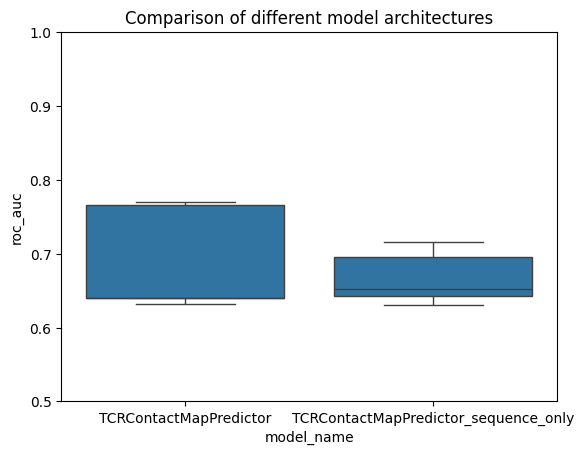

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.689511,0.639685,0.071784
TCRContactMapPredictor_sequence_only,0.667221,0.652702,0.036522


In [7]:
plt.title('Comparison of different model architectures')
plt.ylim([0.5, 1.0])

sns.boxplot(roc_results, x='model_name', y='roc_auc')

plt.show()

roc_results.groupby('model_name')['roc_auc'].agg(['mean', 'median', 'std'])

In [8]:
stats.wilcoxon(
    roc_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['roc_auc'],
    roc_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['roc_auc'],
    alternative='greater',
)

WilcoxonResult(statistic=9.0, pvalue=0.40625)

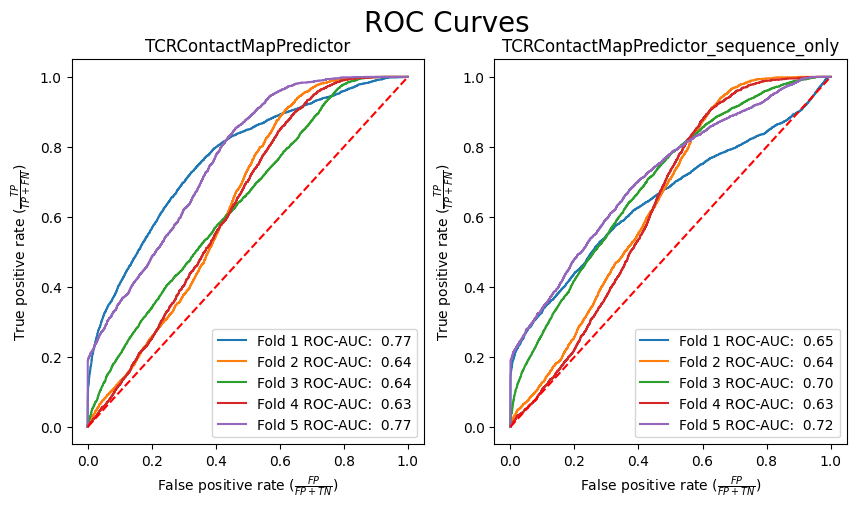

In [9]:
model_groups = roc_results.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('ROC Curves', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]
        group = fold_group.explode(['tpr', 'fpr'])

        axes[i].plot(group['fpr'], group['tpr'], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
    axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

In [10]:
model_groups = roc_results.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

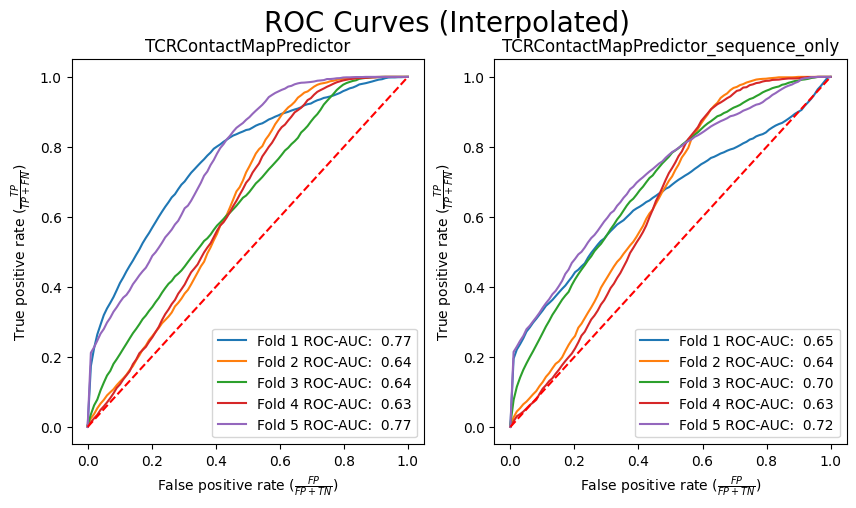

In [11]:
model_groups = roc_results.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('ROC Curves (Interpolated)', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]

        axes[i].plot(fpr_interp, tpr_interp[model_name][fold], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
    axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

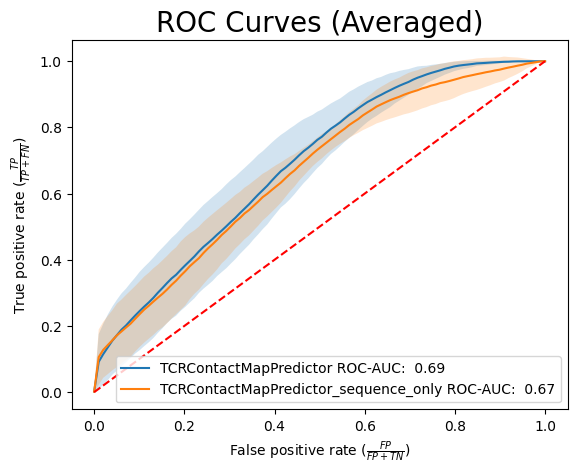

In [12]:
plt.title('ROC Curves (Averaged)', fontsize=20)

for model_name, _ in roc_results.groupby('model_name'):
    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

## Precision-Recall

In [13]:
pr_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['binding'], group['binding_prediction']),
    include_groups=False,
)
pr_results.name = 'pr_curve'
pr_results = pr_results.reset_index()

In [14]:
pr_results[['precision', 'recall', 'threshold']] = pr_results['pr_curve'].apply(pd.Series)

In [15]:
pr_results['pr_auc'] = pr_results.apply(lambda row: metrics.auc(row['recall'], row['precision']), axis=1)

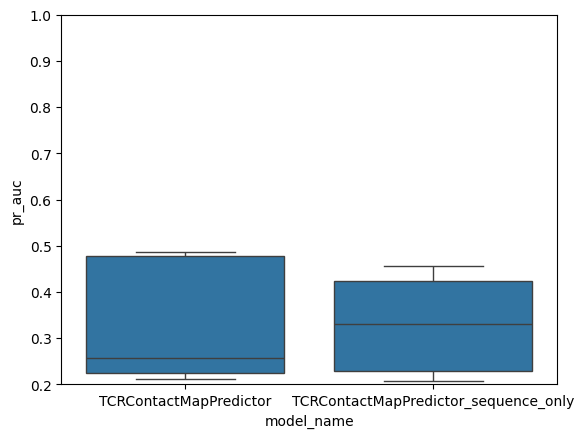

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.331477,0.257160,0.138206
TCRContactMapPredictor_sequence_only,0.329808,0.331819,0.111277


In [16]:
sns.boxplot(pr_results, x='model_name', y='pr_auc')
plt.ylim([0.2, 1.0])

plt.show()

pr_results.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])

In [17]:
stats.wilcoxon(
    pr_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['pr_auc'],
    pr_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['pr_auc'],
    alternative='greater',
)

WilcoxonResult(statistic=8.0, pvalue=0.5)

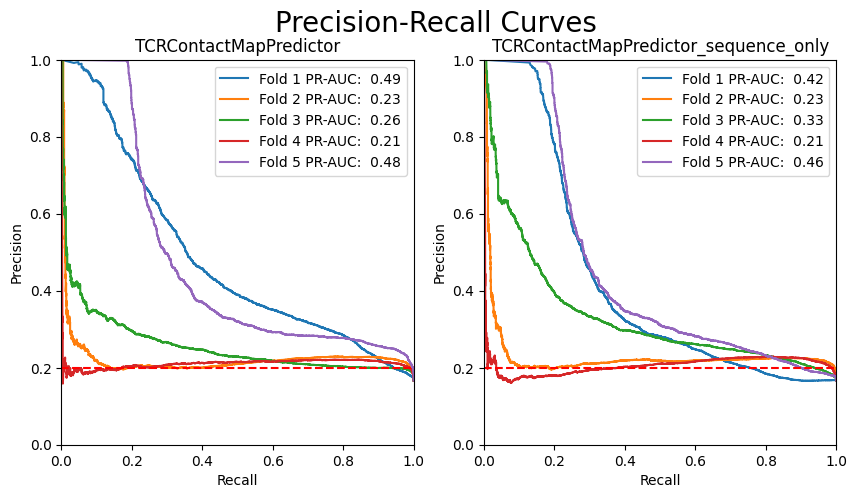

In [18]:
model_groups = pr_results.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('Precision-Recall Curves', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

In [19]:
model_groups = pr_results.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

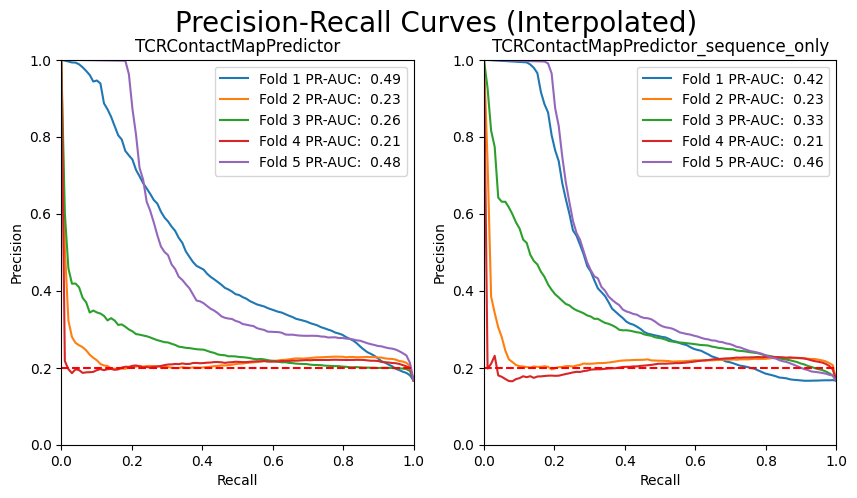

In [20]:
model_groups = pr_results.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('Precision-Recall Curves (Interpolated)', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

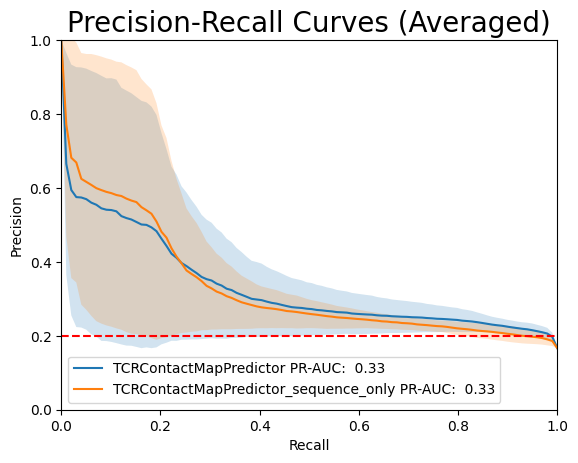

In [21]:
plt.title('Precision-Recall Curves (Averaged)', fontsize=20)

for model_name, _ in pr_results.groupby('model_name'):
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()

plt.show()

### Balancing classes

In [22]:
def down_sample_group(group: pd.DataFrame, random_state: int | np.random.Generator | None = None) -> pd.DataFrame:
    positives = group[group['binding'] == 1]
    negatives = group[group['non_binding'] == 1]

    num_positives = len(positives)
    num_negatives = len(negatives)

    if num_positives > num_negatives:
        return pd.concat([positives.sample(num_negatives, random_state=random_state), negatives])

    if num_positives < num_negatives:
        return pd.concat([positives, negatives.sample(num_positives, random_state=random_state)])

    return group


rng = np.random.default_rng(123)
balanced_predictions = (
    predictions.groupby(['model_name', 'fold'])
    .apply(
        down_sample_group,
        random_state=rng,
        include_groups=False,
    )
    .reset_index()
)

In [23]:
pr_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['binding'], group['binding_prediction']),
    include_groups=False,
)
pr_results_balanced.name = 'pr_curve'
pr_results_balanced = pr_results_balanced.reset_index()

In [24]:
pr_results_balanced[['precision', 'recall', 'threshold']] = pr_results_balanced['pr_curve'].apply(pd.Series)

In [25]:
pr_results_balanced['pr_auc'] = pr_results_balanced.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

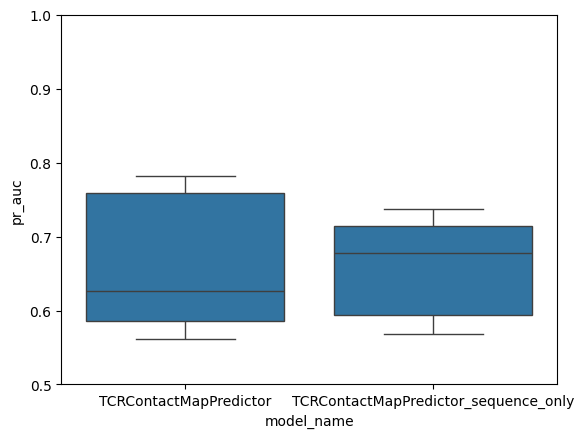

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.663098,0.626447,0.101337
TCRContactMapPredictor_sequence_only,0.658422,0.677602,0.074567


In [26]:
sns.boxplot(pr_results_balanced, x='model_name', y='pr_auc')
plt.ylim([0.5, 1.0])
plt.show()

pr_results_balanced.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])

In [27]:
stats.wilcoxon(
    pr_results_balanced.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['pr_auc'],
    pr_results_balanced.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['pr_auc'],
    alternative='greater',
)

WilcoxonResult(statistic=8.0, pvalue=0.5)

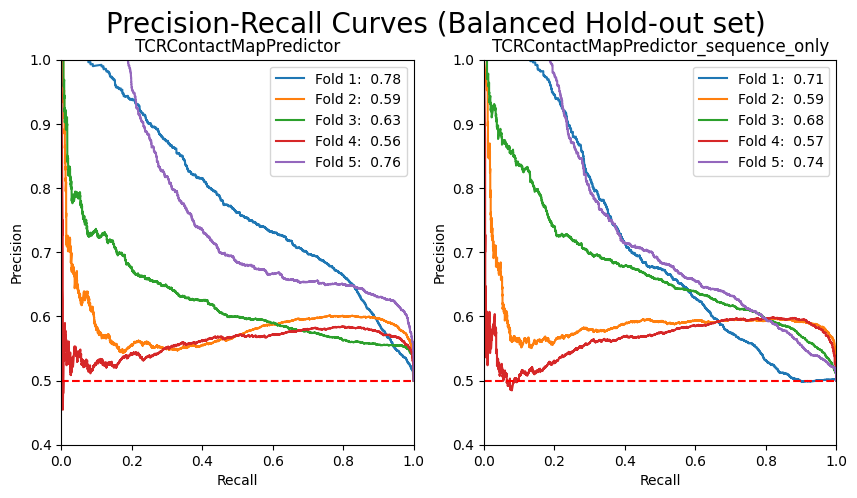

In [28]:
model_groups = pr_results_balanced.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set)', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold}: {roc_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

In [29]:
model_groups = pr_results_balanced.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

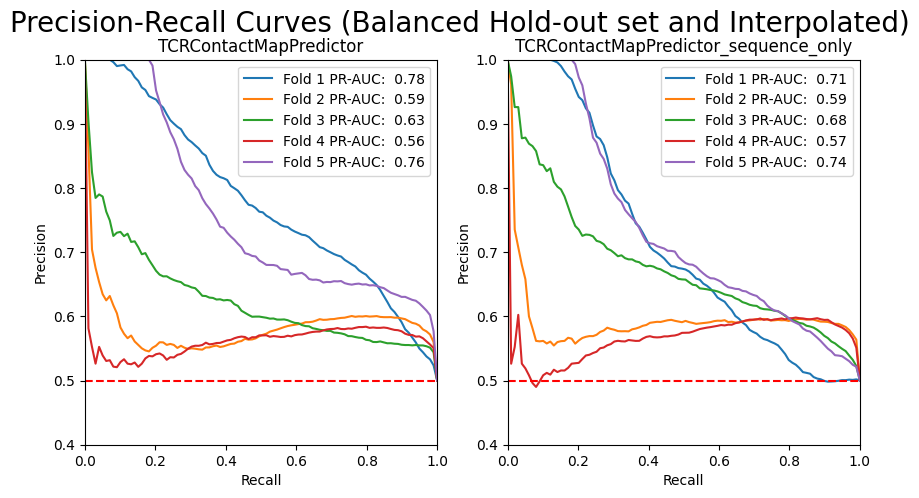

In [30]:
model_groups = pr_results_balanced.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set and Interpolated)', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

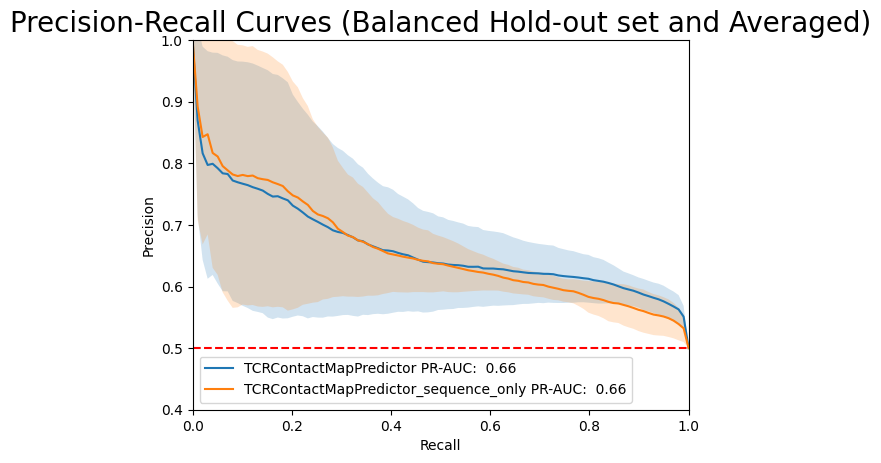

In [31]:
plt.title('Precision-Recall Curves (Balanced Hold-out set and Averaged)', fontsize=20)

for model_name, _ in pr_results_balanced.groupby('model_name'):
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.plot([0, 1], [0.5, 0.5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0.4, 1])
plt.legend()

plt.show()

## F1-Score

In [32]:
THRESHOLD = 0.5
predictions['binding_prediction_binary'] = (predictions['binding_prediction'] > THRESHOLD).apply(int)
predictions['non_binding_prediction_binary'] = (predictions['non_binding_prediction'] > THRESHOLD).apply(int)

In [33]:
f1_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['binding'], row['binding_prediction_binary']),
    include_groups=False,
)
f1_results.name = 'f1_score'
f1_results = f1_results.reset_index()

f1_results.pivot_table(index='fold', columns='model_name', values='f1_score')

model_name,TCRContactMapPredictor,TCRContactMapPredictor_sequence_only
fold,,
1,0.398732,0.362147
2,0.145320,0.159399
3,0.195931,0.296319
4,0.145027,0.127586
5,0.375813,0.363437


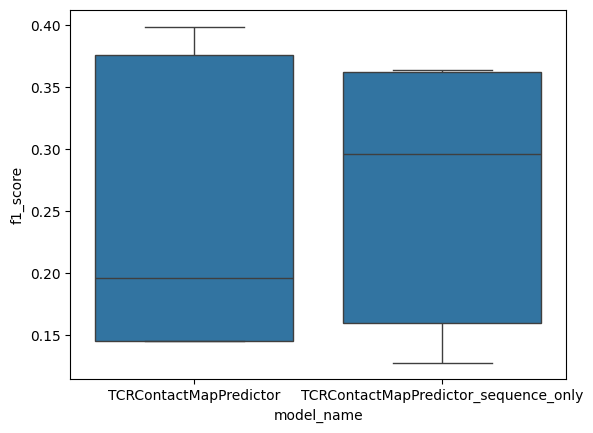

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.252165,0.195931,0.125327
TCRContactMapPredictor_sequence_only,0.261778,0.296319,0.111905


In [34]:
sns.boxplot(f1_results, x='model_name', y='f1_score')
plt.show()

f1_results.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])

In [35]:
stats.wilcoxon(
    f1_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['f1_score'],
    f1_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['f1_score'],
    alternative='greater',
)

WilcoxonResult(statistic=8.0, pvalue=0.5)

### Balancing classes

In [36]:
balanced_predictions['binding_prediction_binary'] = (balanced_predictions['binding_prediction'] > THRESHOLD).apply(int)
balanced_predictions['non_binding_prediction_binary'] = (
    balanced_predictions['non_binding_prediction'] > THRESHOLD
).apply(int)

In [37]:
f1_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['binding'], row['binding_prediction_binary']),
    include_groups=False,
)
f1_results_balanced.name = 'f1_score'
f1_results_balanced = f1_results_balanced.reset_index()

f1_results_balanced.pivot_table(index='fold', columns='model_name', values='f1_score')

model_name,TCRContactMapPredictor,TCRContactMapPredictor_sequence_only
fold,,
1,0.452033,0.440655
2,0.185637,0.214402
3,0.233708,0.376312
4,0.189088,0.168373
5,0.443946,0.430191


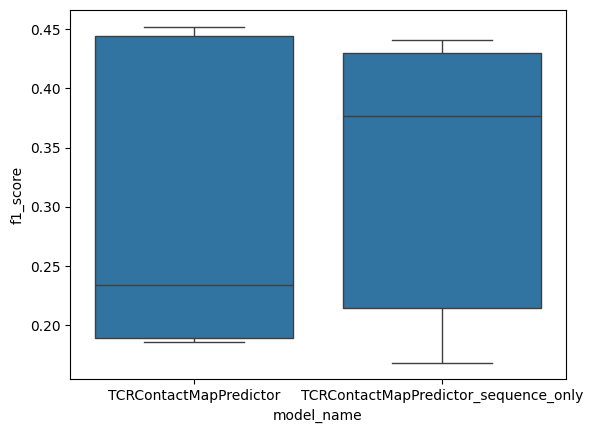

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.300882,0.233708,0.135652
TCRContactMapPredictor_sequence_only,0.325987,0.376312,0.126326


In [38]:
sns.boxplot(f1_results_balanced, x='model_name', y='f1_score')
plt.show()

f1_results_balanced.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])

In [39]:
stats.wilcoxon(
    f1_results_balanced.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['f1_score'],
    f1_results_balanced.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['f1_score'],
    alternative='greater',
)

WilcoxonResult(statistic=6.0, pvalue=0.6875)